In [3]:
# ==================== CELL 1: Import Libraries ====================
"""
Import semua library yang diperlukan untuk:
- Deep Learning (TensorFlow/Keras)
- Image Processing (OpenCV)
- Metrics & Visualization
"""

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50V2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seeds untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set style untuk plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("✓ Libraries loaded successfully")
print("="*70)
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print("="*70)

Library berhasil diimport!


In [11]:
# Configuration
BASE_DIR = r"dataset"  # EDIT sesuai lokasi dataset kamu

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 10
EPOCHS_STAGE2 = 20
LEARNING_RATE_1 = 1e-4
LEARNING_RATE_2 = 1e-5

# Results folder
RESULTS_DIR = "experiment_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Verify paths
print("="*70)
print("Verifying dataset paths...")
print("="*70)

paths_status = []
for name, path in [("Base Directory", BASE_DIR), 
                   ("Train Directory", TRAIN_DIR),
                   ("Validation Directory", VAL_DIR), 
                   ("Test Directory", TEST_DIR)]:
    exists = os.path.exists(path)
    status = "EXISTS" if exists else "NOT FOUND"
    paths_status.append(exists)
    print(f"{name:20s}: {status}")
    print(f"  Path: {path}")

print("="*70)

if all(paths_status):
    print("All paths verified successfully")
    print(f"Results will be saved to: {RESULTS_DIR}")
else:
    print("ERROR: Some paths not found")
    print("Please check your BASE_DIR setting")
    
print("="*70)

# Display configuration
print("\n" + "="*70)
print("Experiment Configuration")
print("="*70)
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs Stage 1: {EPOCHS_STAGE1}")
print(f"Epochs Stage 2: {EPOCHS_STAGE2}")
print(f"Learning Rate Stage 1: {LEARNING_RATE_1}")
print(f"Learning Rate Stage 2: {LEARNING_RATE_2}")
print("="*70)

Verifying dataset paths...
Base Directory      : EXISTS
  Path: dataset
Train Directory     : EXISTS
  Path: dataset\train
Validation Directory: EXISTS
  Path: dataset\val
Test Directory      : EXISTS
  Path: dataset\test
All paths verified successfully
Results will be saved to: experiment_results

Experiment Configuration
Image Size: (224, 224)
Batch Size: 32
Epochs Stage 1: 10
Epochs Stage 2: 20
Learning Rate Stage 1: 0.0001
Learning Rate Stage 2: 1e-05


In [12]:
# Preprocessing Functions

def preprocess_clahe(image):
    """
    CLAHE - Contrast Limited Adaptive Histogram Equalization
    
    Purpose: Enhance local contrast
    Input: uint8 image (0-255)
    Output: uint8 image (0-255)
    """
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return enhanced


def preprocess_green_clahe(image):
    """
    Green Channel + CLAHE
    
    Purpose: Extract green channel (best for fundus) + enhance contrast
    Input: uint8 image (0-255)
    Output: uint8 image (0-255)
    """
    green_channel = image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_green = clahe.apply(green_channel)
    enhanced_rgb = cv2.merge([enhanced_green, enhanced_green, enhanced_green])
    return enhanced_rgb


def preprocess_clahe_sharpen(image, kernel_size=(5, 5), sigma=1.0, amount=1.5):
    """
    CLAHE + Unsharp Masking
    
    Purpose: Enhance contrast + sharpen details (anti-blur)
    Input: uint8 image (0-255)
    Output: uint8 image (0-255)
    """
    # Step 1: CLAHE
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Step 2: Unsharp masking
    blurred = cv2.GaussianBlur(enhanced, kernel_size, sigma)
    sharpened = cv2.addWeighted(enhanced, 1.0 + amount, blurred, -amount, 0)
    
    return sharpened


# Test preprocessing functions
print("="*70)
print("Testing preprocessing functions...")
print("="*70)

test_image = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)

functions_to_test = [
    ("CLAHE", preprocess_clahe),
    ("Green + CLAHE", preprocess_green_clahe),
    ("CLAHE + Sharpen", preprocess_clahe_sharpen)
]

all_passed = True

for name, func in functions_to_test:
    try:
        result = func(test_image)
        assert result.shape == test_image.shape, "Shape mismatch"
        assert result.dtype == np.uint8, "Dtype should be uint8"
        print(f"{name:20s}: PASSED")
    except Exception as e:
        print(f"{name:20s}: FAILED - {str(e)}")
        all_passed = False

print("="*70)

if all_passed:
    print("All preprocessing functions working correctly")
else:
    print("Some functions failed")

print("="*70)

# Summary
print("\n" + "="*70)
print("Preprocessing Methods Summary")
print("="*70)
print(f"{'Method':<25} {'Expected Acc Gain':<20} {'Expected Speed Cost'}")
print("-"*70)
print(f"{'CLAHE':<25} {'+3-5%':<20} {'+6-8 ms'}")
print(f"{'Green + CLAHE':<25} {'+4-7%':<20} {'+10-12 ms'}")
print(f"{'CLAHE + Sharpen':<25} {'+5-8%':<20} {'+14-16 ms'}")
print("="*70)

Testing preprocessing functions...
CLAHE               : PASSED
Green + CLAHE       : PASSED
CLAHE + Sharpen     : PASSED
All preprocessing functions working correctly

Preprocessing Methods Summary
Method                    Expected Acc Gain    Expected Speed Cost
----------------------------------------------------------------------
CLAHE                     +3-5%                +6-8 ms
Green + CLAHE             +4-7%                +10-12 ms
CLAHE + Sharpen           +5-8%                +14-16 ms


Loading dataset information...
Found 1531 images belonging to 2 classes.
Found 317 images belonging to 2 classes.
Found 264 images belonging to 2 classes.

Dataset Statistics
Classes: ['Cataract', 'Normal']
  0: Cataract
  1: Normal

----------------------------------------------------------------------
Split           Total Images    Class 0         Class 1        
----------------------------------------------------------------------
Training        1531            779             752            
Validation      317             156             161            
Test            264             103             161            
----------------------------------------------------------------------
TOTAL           2112           

Computing class weights...
Class Weights:
  Class 0 (Cataract       ): 0.9827
  Class 1 (Normal         ): 1.0180

Imbalance Ratio: 1.04:1
  Dataset is relatively balanced

Visualizing sample images...


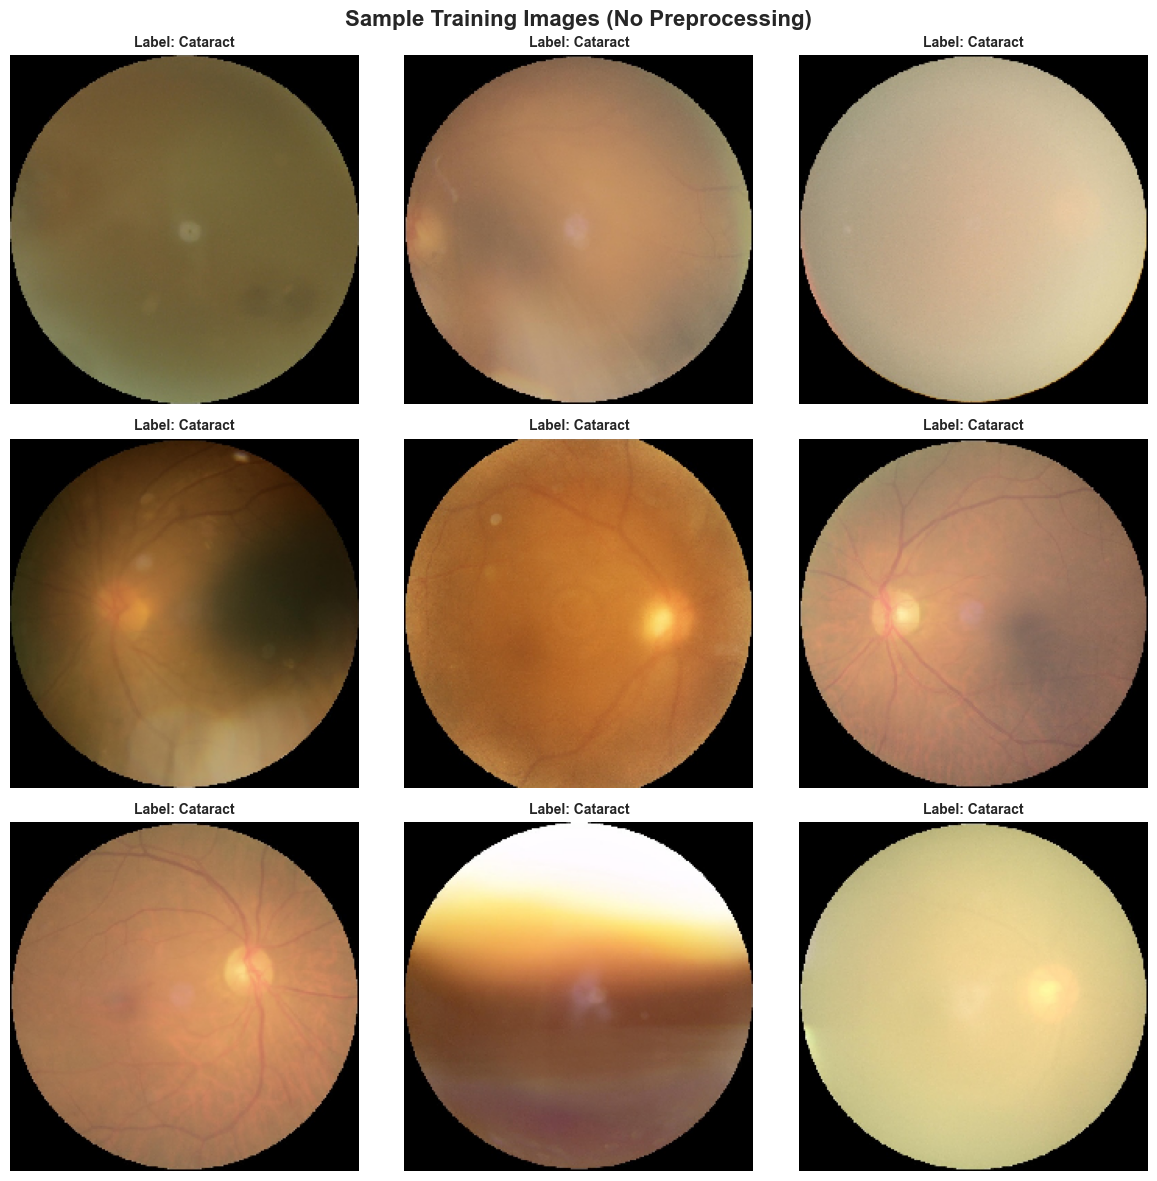

Sample images displayed

Collected 20 sample image paths for benchmarking

Dataset loading complete
Training samples: 1531
Validation samples: 317
Test samples: 264
Classes: ['Cataract', 'Normal']
Class weights: {0: 0.9826700898587933, 1: 1.0179521276595744}


In [14]:
# Load Dataset

print("="*70)
print("Loading dataset information...")
print("="*70)

# Create temporary generator untuk count images
temp_gen = ImageDataGenerator(rescale=1./255)

train_temp = temp_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

val_temp = temp_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_temp = temp_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Dataset statistics
print("\n" + "="*70)
print("Dataset Statistics")
print("="*70)

class_names = list(train_temp.class_indices.keys())
print(f"Classes: {class_names}")
print(f"  0: {class_names[0]}")
print(f"  1: {class_names[1]}")

print("\n" + "-"*70)
print(f"{'Split':<15} {'Total Images':<15} {'Class 0':<15} {'Class 1':<15}")
print("-"*70)

train_class_0 = np.sum(train_temp.classes == 0)
train_class_1 = np.sum(train_temp.classes == 1)
print(f"{'Training':<15} {train_temp.samples:<15} {train_class_0:<15} {train_class_1:<15}")

val_class_0 = np.sum(val_temp.classes == 0)
val_class_1 = np.sum(val_temp.classes == 1)
print(f"{'Validation':<15} {val_temp.samples:<15} {val_class_0:<15} {val_class_1:<15}")

test_class_0 = np.sum(test_temp.classes == 0)
test_class_1 = np.sum(test_temp.classes == 1)
print(f"{'Test':<15} {test_temp.samples:<15} {test_class_0:<15} {test_class_1:<15}")

print("-"*70)
total_images = train_temp.samples + val_temp.samples + test_temp.samples
print(f"{'TOTAL':<15} {total_images:<15}")
print("="*70)

# Compute class weights
print("\n" + "="*70)
print("Computing class weights...")
print("="*70)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_temp.classes),
    y=train_temp.classes
)

class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:")
for class_idx, weight in class_weight_dict.items():
    class_name = class_names[class_idx]
    print(f"  Class {class_idx} ({class_name:15s}): {weight:.4f}")

imbalance_ratio = max(train_class_0, train_class_1) / min(train_class_0, train_class_1)
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("  Dataset is imbalanced - class weights will help")
else:
    print("  Dataset is relatively balanced")

print("="*70)

# Visualize sample images
print("\n" + "="*70)
print("Visualizing sample images...")
print("="*70)

sample_batch = next(train_temp)
sample_images = sample_batch[0][:9]
sample_labels = sample_batch[1][:9]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Sample Training Images (No Preprocessing)', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_images):
        ax.imshow(sample_images[idx])
        label_name = class_names[int(sample_labels[idx])]
        ax.set_title(f'Label: {label_name}', fontsize=10, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("Sample images displayed")
print("="*70)

# Collect sample image paths untuk preprocessing benchmarking nanti
sample_img_paths = []
for class_folder in os.listdir(TEST_DIR):
    class_path = os.path.join(TEST_DIR, class_folder)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path)[:10]:
            img_file = os.path.join(class_path, img_name)
            if os.path.isfile(img_file) and img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                sample_img_paths.append(img_file)

print(f"\nCollected {len(sample_img_paths)} sample image paths for benchmarking")

print("\n" + "="*70)
print("Dataset loading complete")
print("="*70)
print(f"Training samples: {train_temp.samples}")
print(f"Validation samples: {val_temp.samples}")
print(f"Test samples: {test_temp.samples}")
print(f"Classes: {class_names}")
print(f"Class weights: {class_weight_dict}")
print("="*70)

In [ ]:
# BASELINE - No Preprocessing
# Run ONLY ONE of Cell 5A/5B/5C/5D
# If you want to test different preprocessing, restart kernel first

print("="*70)
print("EXPERIMENT: BASELINE (No Preprocessing)")
print("="*70)

EXPERIMENT_NAME = "BASELINE"
PREPROCESSING_METHOD = "None (rescale only)"

print(f"\nExperiment Name: {EXPERIMENT_NAME}")
print(f"Preprocessing: {PREPROCESSING_METHOD}")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Create data generators - NO augmentation for medical images
print("\n" + "="*70)
print("Creating data generators...")
print("="*70)
print("Medical Imaging Mode: NO AUGMENTATION")
print("="*70)

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Test batches: {len(test_data)}")

# Visualize
print("\n" + "="*70)
print("Visualizing baseline images...")
print("="*70)

sample_batch = next(train_data)
sample_images = sample_batch[0][:6]
sample_labels = sample_batch[1][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('BASELINE - Original Images', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_images):
        ax.imshow(sample_images[idx])
        label_name = class_names[int(sample_labels[idx])]
        ax.set_title(f'Label: {label_name}', fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Measure preprocessing time
print("\n" + "="*70)
print("Measuring preprocessing time...")
print("="*70)

preprocessing_times = []

for img_path in sample_img_paths[:20]:
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    
    start_time = time.time()
    preprocessed = img / 255.0
    end_time = time.time()
    
    preprocessing_times.append((end_time - start_time) * 1000)

avg_preprocessing_time = np.mean(preprocessing_times)
std_preprocessing_time = np.std(preprocessing_times)

print(f"Preprocessing Time Statistics ({len(preprocessing_times)} images):")
print(f"  Average: {avg_preprocessing_time:.3f} ms per image")
print(f"  Std Dev: {std_preprocessing_time:.3f} ms")
print(f"  Min: {np.min(preprocessing_times):.3f} ms")
print(f"  Max: {np.max(preprocessing_times):.3f} ms")
print(f"  Throughput: ~{1000/avg_preprocessing_time:.0f} images/second")

# Summary
print("\n" + "="*70)
print("BASELINE Experiment Setup Complete")
print("="*70)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Preprocessing: {PREPROCESSING_METHOD}")
print(f"Avg Preprocessing Time: {avg_preprocessing_time:.3f} ms per image")
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Test samples: {test_data.samples}")
print("="*70)

experiment_info = {
    'name': EXPERIMENT_NAME,
    'preprocessing': PREPROCESSING_METHOD,
    'avg_preprocessing_time_ms': round(avg_preprocessing_time, 3),
    'std_preprocessing_time_ms': round(std_preprocessing_time, 3),
    'throughput_img_per_sec': round(1000/avg_preprocessing_time, 0),
    'train_samples': train_data.samples,
    'val_samples': val_data.samples,
    'test_samples': test_data.samples,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

print("\nReady for training - Next: Run Cell 6")
print("="*70)

In [ ]:
# CLAHE Preprocessing
# Run ONLY ONE of Cell 5A/5B/5C/5D
# If you want to test different preprocessing, restart kernel first

print("="*70)
print("EXPERIMENT: CLAHE Preprocessing")
print("="*70)

EXPERIMENT_NAME = "CLAHE"
PREPROCESSING_METHOD = "CLAHE (Contrast Limited Adaptive Histogram Equalization)"

print(f"\nExperiment Name: {EXPERIMENT_NAME}")
print(f"Preprocessing: {PREPROCESSING_METHOD}")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Custom preprocessing function
def custom_preprocessing_clahe(image):
    img_uint8 = (image * 255).astype(np.uint8)
    processed_uint8 = preprocess_clahe(img_uint8)
    processed_float = processed_uint8.astype(np.float32) / 255.0
    return processed_float

# Create data generators
print("\n" + "="*70)
print("Creating data generators with CLAHE...")
print("="*70)
print("Medical Imaging Mode: NO AUGMENTATION")
print("Preprocessing: CLAHE")
print("="*70)

train_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing_clahe)
val_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing_clahe)
test_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing_clahe)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Test batches: {len(test_data)}")

# Visualize before/after
print("\n" + "="*70)
print("Visualizing CLAHE preprocessing...")
print("="*70)

if sample_img_paths:
    original = cv2.imread(sample_img_paths[0])
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    original = cv2.resize(original, IMG_SIZE)
    clahe_processed = preprocess_clahe(original)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(original)
    axes[0].set_title('ORIGINAL', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(clahe_processed)
    axes[1].set_title('AFTER CLAHE', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.suptitle('CLAHE Preprocessing', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

sample_batch = next(train_data)
sample_images = sample_batch[0][:6]
sample_labels = sample_batch[1][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('CLAHE Preprocessed Images', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_images):
        ax.imshow(sample_images[idx])
        label_name = class_names[int(sample_labels[idx])]
        ax.set_title(f'Label: {label_name}', fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Measure preprocessing time
print("\n" + "="*70)
print("Measuring preprocessing time...")
print("="*70)

preprocessing_times = []

for img_path in sample_img_paths[:20]:
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    
    start_time = time.time()
    preprocessed = preprocess_clahe(img)
    preprocessed = preprocessed / 255.0
    end_time = time.time()
    
    preprocessing_times.append((end_time - start_time) * 1000)

avg_preprocessing_time = np.mean(preprocessing_times)
std_preprocessing_time = np.std(preprocessing_times)
baseline_time = 2.5
overhead = avg_preprocessing_time - baseline_time

print(f"CLAHE Preprocessing Time Statistics ({len(preprocessing_times)} images):")
print(f"  Average: {avg_preprocessing_time:.3f} ms per image")
print(f"  Std Dev: {std_preprocessing_time:.3f} ms")
print(f"  Throughput: ~{1000/avg_preprocessing_time:.0f} images/second")
print(f"\nOverhead vs Baseline:")
print(f"  Baseline: ~{baseline_time:.1f} ms")
print(f"  CLAHE: {avg_preprocessing_time:.3f} ms")
print(f"  Additional cost: +{overhead:.3f} ms")

# Summary
print("\n" + "="*70)
print("CLAHE Experiment Setup Complete")
print("="*70)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Preprocessing: {PREPROCESSING_METHOD}")
print(f"Avg Preprocessing Time: {avg_preprocessing_time:.3f} ms per image")
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Test samples: {test_data.samples}")
print("="*70)

experiment_info = {
    'name': EXPERIMENT_NAME,
    'preprocessing': PREPROCESSING_METHOD,
    'avg_preprocessing_time_ms': round(avg_preprocessing_time, 3),
    'std_preprocessing_time_ms': round(std_preprocessing_time, 3),
    'overhead_vs_baseline_ms': round(overhead, 3),
    'throughput_img_per_sec': round(1000/avg_preprocessing_time, 0),
    'train_samples': train_data.samples,
    'val_samples': val_data.samples,
    'test_samples': test_data.samples,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

print("\nReady for training - Next: Run Cell 6")
print("="*70)

In [ ]:
# Green Channel + CLAHE Preprocessing
# Run ONLY ONE of Cell 5A/5B/5C/5D
# If you want to test different preprocessing, restart kernel first

print("="*70)
print("EXPERIMENT: Green Channel + CLAHE")
print("="*70)

EXPERIMENT_NAME = "GREEN_CLAHE"
PREPROCESSING_METHOD = "Green Channel + CLAHE"

print(f"\nExperiment Name: {EXPERIMENT_NAME}")
print(f"Preprocessing: {PREPROCESSING_METHOD}")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Custom preprocessing function
def custom_preprocessing_green_clahe(image):
    img_uint8 = (image * 255).astype(np.uint8)
    processed_uint8 = preprocess_green_clahe(img_uint8)
    processed_float = processed_uint8.astype(np.float32) / 255.0
    return processed_float

# Create data generators
print("\n" + "="*70)
print("Creating data generators with Green + CLAHE...")
print("="*70)
print("Medical Imaging Mode: NO AUGMENTATION")
print("Preprocessing: Green Channel + CLAHE")
print("="*70)

train_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing_green_clahe)
val_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing_green_clahe)
test_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing_green_clahe)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Test batches: {len(test_data)}")

# Visualize
print("\n" + "="*70)
print("Visualizing Green + CLAHE preprocessing...")
print("="*70)

if sample_img_paths:
    original = cv2.imread(sample_img_paths[0])
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    original = cv2.resize(original, IMG_SIZE)
    
    red_channel = original[:, :, 0]
    green_channel = original[:, :, 1]
    blue_channel = original[:, :, 2]
    green_clahe = preprocess_green_clahe(original)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    axes[0, 0].imshow(original)
    axes[0, 0].set_title('ORIGINAL RGB', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(red_channel, cmap='Reds')
    axes[0, 1].set_title('RED CHANNEL', fontsize=12)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(blue_channel, cmap='Blues')
    axes[0, 2].set_title('BLUE CHANNEL', fontsize=12)
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(green_channel, cmap='Greens')
    axes[1, 0].set_title('GREEN CHANNEL (Best)', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(green_clahe, cmap='gray')
    axes[1, 1].set_title('GREEN + CLAHE', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(green_clahe)
    axes[1, 2].set_title('FINAL OUTPUT', fontsize=12, fontweight='bold')
    axes[1, 2].axis('off')
    
    plt.suptitle('Green Channel + CLAHE Pipeline', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

sample_batch = next(train_data)
sample_images = sample_batch[0][:6]
sample_labels = sample_batch[1][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Green + CLAHE Preprocessed Images', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_images):
        ax.imshow(sample_images[idx], cmap='gray')
        label_name = class_names[int(sample_labels[idx])]
        ax.set_title(f'Label: {label_name}', fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Measure preprocessing time
print("\n" + "="*70)
print("Measuring preprocessing time...")
print("="*70)

preprocessing_times = []

for img_path in sample_img_paths[:20]:
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    
    start_time = time.time()
    preprocessed = preprocess_green_clahe(img)
    preprocessed = preprocessed / 255.0
    end_time = time.time()
    
    preprocessing_times.append((end_time - start_time) * 1000)

avg_preprocessing_time = np.mean(preprocessing_times)
std_preprocessing_time = np.std(preprocessing_times)
baseline_time = 2.5
overhead = avg_preprocessing_time - baseline_time

print(f"Green+CLAHE Preprocessing Time Statistics ({len(preprocessing_times)} images):")
print(f"  Average: {avg_preprocessing_time:.3f} ms per image")
print(f"  Std Dev: {std_preprocessing_time:.3f} ms")
print(f"  Throughput: ~{1000/avg_preprocessing_time:.0f} images/second")
print(f"\nComparison:")
print(f"  Baseline: ~{baseline_time:.1f} ms")
print(f"  Green+CLAHE: {avg_preprocessing_time:.3f} ms")
print(f"  Additional cost: +{overhead:.3f} ms")

# Summary
print("\n" + "="*70)
print("GREEN + CLAHE Experiment Setup Complete")
print("="*70)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Preprocessing: {PREPROCESSING_METHOD}")
print(f"Avg Preprocessing Time: {avg_preprocessing_time:.3f} ms per image")
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Test samples: {test_data.samples}")
print("="*70)

experiment_info = {
    'name': EXPERIMENT_NAME,
    'preprocessing': PREPROCESSING_METHOD,
    'avg_preprocessing_time_ms': round(avg_preprocessing_time, 3),
    'std_preprocessing_time_ms': round(std_preprocessing_time, 3),
    'overhead_vs_baseline_ms': round(overhead, 3),
    'throughput_img_per_sec': round(1000/avg_preprocessing_time, 0),
    'train_samples': train_data.samples,
    'val_samples': val_data.samples,
    'test_samples': test_data.samples,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

print("\nReady for training - Next: Run Cell 6")
print("="*70)

EXPERIMENT: CLAHE + Sharpening

Experiment Name: CLAHE_SHARPEN
Preprocessing: CLAHE + Unsharp Masking
Start Time: 2025-11-20 08:59:50

Creating data generators with CLAHE + Sharpen...
Medical Imaging Mode: NO AUGMENTATION
Preprocessing: CLAHE + Unsharp Masking
Found 1531 images belonging to 2 classes.
Found 317 images belonging to 2 classes.
Found 264 images belonging to 2 classes.
Training batches: 48
Validation batches: 10
Test batches: 9

Visualizing CLAHE + Sharpening pipeline...


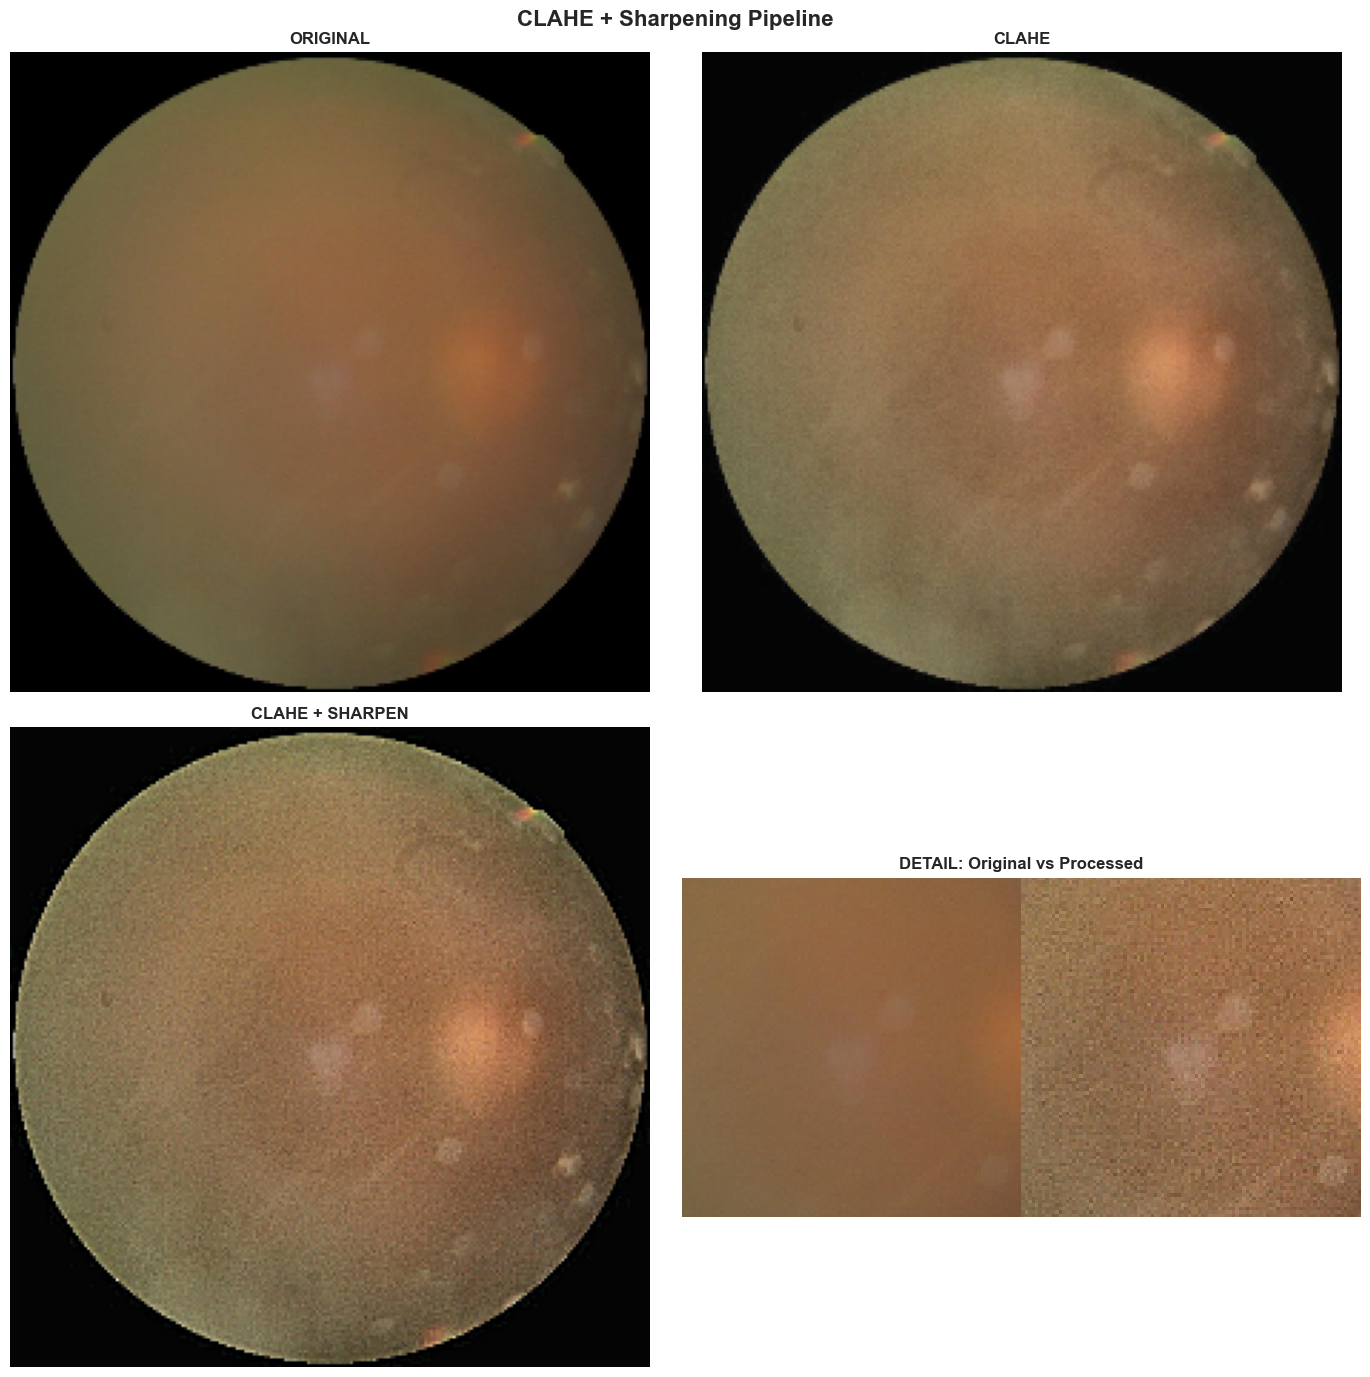

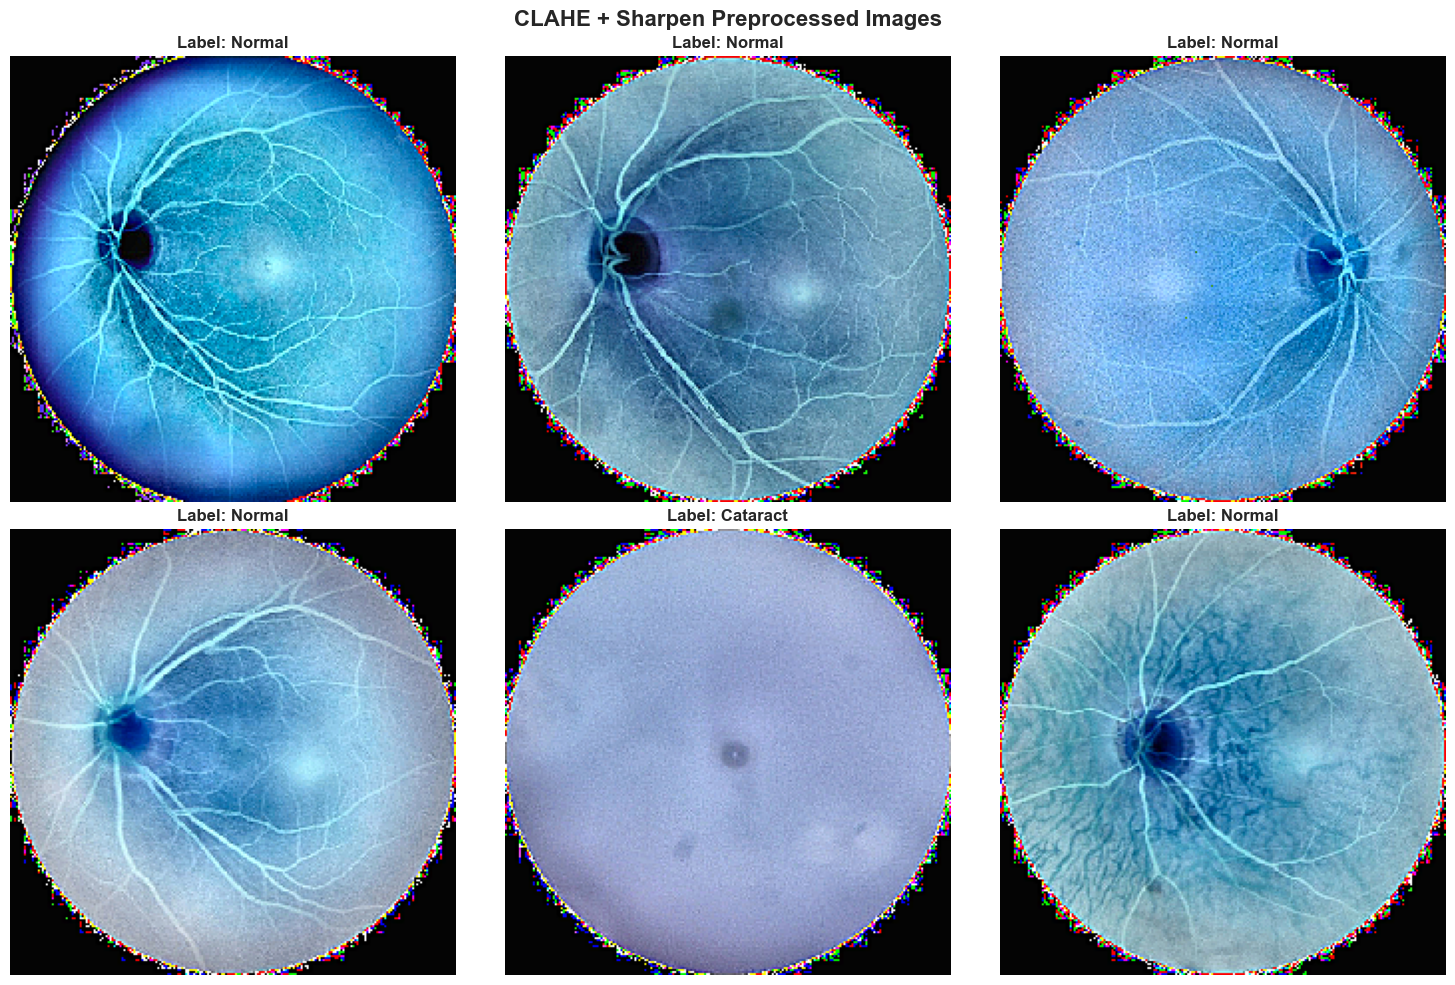


Measuring preprocessing time...
CLAHE+Sharpen Time Statistics (20 images):
  Average: 1.753 ms per image
  Std Dev: 0.537 ms
  Throughput: ~571 images/second

Full Comparison:
  Baseline: ~2.5 ms
  CLAHE+Sharpen: 1.753 ms (SLOWEST)
  Additional cost: +-0.747 ms

CLAHE + SHARPENING Experiment Setup Complete
Experiment: CLAHE_SHARPEN
Preprocessing: CLAHE + Unsharp Masking
Avg Preprocessing Time: 1.753 ms per image
Training samples: 1531
Validation samples: 317
Test samples: 264

Ready for training - Next: Run Cell 6


In [15]:
# CLAHE + Sharpening Preprocessing
# Run ONLY ONE of Cell 5A/5B/5C/5D
# If you want to test different preprocessing, restart kernel first

print("="*70)
print("EXPERIMENT: CLAHE + Sharpening")
print("="*70)

EXPERIMENT_NAME = "CLAHE_SHARPEN"
PREPROCESSING_METHOD = "CLAHE + Unsharp Masking"

print(f"\nExperiment Name: {EXPERIMENT_NAME}")
print(f"Preprocessing: {PREPROCESSING_METHOD}")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Custom preprocessing function
def custom_preprocessing_clahe_sharpen(image):
    img_uint8 = (image * 255).astype(np.uint8)
    processed_uint8 = preprocess_clahe_sharpen(img_uint8)
    processed_float = processed_uint8.astype(np.float32) / 255.0
    return processed_float

# Create data generators
print("\n" + "="*70)
print("Creating data generators with CLAHE + Sharpen...")
print("="*70)
print("Medical Imaging Mode: NO AUGMENTATION")
print("Preprocessing: CLAHE + Unsharp Masking")
print("="*70)

train_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing_clahe_sharpen)
val_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing_clahe_sharpen)
test_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing_clahe_sharpen)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Test batches: {len(test_data)}")

# Visualize pipeline
print("\n" + "="*70)
print("Visualizing CLAHE + Sharpening pipeline...")
print("="*70)

if sample_img_paths:
    original = cv2.imread(sample_img_paths[0])
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    original = cv2.resize(original, IMG_SIZE)
    clahe_only = preprocess_clahe(original)
    clahe_sharpen = preprocess_clahe_sharpen(original)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    
    axes[0, 0].imshow(original)
    axes[0, 0].set_title('ORIGINAL', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(clahe_only)
    axes[0, 1].set_title('CLAHE', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(clahe_sharpen)
    axes[1, 0].set_title('CLAHE + SHARPEN', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    h, w = original.shape[:2]
    crop_size = 100
    y_start, x_start = h//2 - crop_size//2, w//2 - crop_size//2
    original_crop = original[y_start:y_start+crop_size, x_start:x_start+crop_size]
    sharpen_crop = clahe_sharpen[y_start:y_start+crop_size, x_start:x_start+crop_size]
    comparison_crop = np.hstack([original_crop, sharpen_crop])
    
    axes[1, 1].imshow(comparison_crop)
    axes[1, 1].set_title('DETAIL: Original vs Processed', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.suptitle('CLAHE + Sharpening Pipeline', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

sample_batch = next(train_data)
sample_images = sample_batch[0][:6]
sample_labels = sample_batch[1][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('CLAHE + Sharpen Preprocessed Images', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_images):
        ax.imshow(sample_images[idx])
        label_name = class_names[int(sample_labels[idx])]
        ax.set_title(f'Label: {label_name}', fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Measure preprocessing time
print("\n" + "="*70)
print("Measuring preprocessing time...")
print("="*70)

preprocessing_times = []

for img_path in sample_img_paths[:20]:
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    
    start_time = time.time()
    preprocessed = preprocess_clahe_sharpen(img)
    preprocessed = preprocessed / 255.0
    end_time = time.time()
    
    preprocessing_times.append((end_time - start_time) * 1000)

avg_preprocessing_time = np.mean(preprocessing_times)
std_preprocessing_time = np.std(preprocessing_times)
baseline_time = 2.5
overhead = avg_preprocessing_time - baseline_time

print(f"CLAHE+Sharpen Time Statistics ({len(preprocessing_times)} images):")
print(f"  Average: {avg_preprocessing_time:.3f} ms per image")
print(f"  Std Dev: {std_preprocessing_time:.3f} ms")
print(f"  Throughput: ~{1000/avg_preprocessing_time:.0f} images/second")
print(f"\nFull Comparison:")
print(f"  Baseline: ~{baseline_time:.1f} ms")
print(f"  CLAHE+Sharpen: {avg_preprocessing_time:.3f} ms (SLOWEST)")
print(f"  Additional cost: +{overhead:.3f} ms")

# Summary
print("\n" + "="*70)
print("CLAHE + SHARPENING Experiment Setup Complete")
print("="*70)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Preprocessing: {PREPROCESSING_METHOD}")
print(f"Avg Preprocessing Time: {avg_preprocessing_time:.3f} ms per image")
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Test samples: {test_data.samples}")
print("="*70)

experiment_info = {
    'name': EXPERIMENT_NAME,
    'preprocessing': PREPROCESSING_METHOD,
    'avg_preprocessing_time_ms': round(avg_preprocessing_time, 3),
    'std_preprocessing_time_ms': round(std_preprocessing_time, 3),
    'overhead_vs_baseline_ms': round(overhead, 3),
    'throughput_img_per_sec': round(1000/avg_preprocessing_time, 0),
    'train_samples': train_data.samples,
    'val_samples': val_data.samples,
    'test_samples': test_data.samples,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

print("\nReady for training - Next: Run Cell 6")
print("="*70)

In [19]:
# Build Model - MobileNetV2 with Stronger Regularization

print("="*70)
print("Building Model with Stronger Regularization...")
print("="*70)

def create_model(input_shape=(224, 224, 3)):
    """
    Create MobileNetV2 model with custom classifier
    FIXED: Stronger regularization to prevent overfitting
    
    Changes:
    - Removed Dense(256) layer (simpler architecture)
    - Increased Dropout: 0.5 -> 0.6 and 0.3 -> 0.5
    - Stronger L2 regularization: 0.01 -> 0.02
    - Added Dropout after BatchNormalization
    """
    
    # Load MobileNetV2 base model
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze base model initially (for Stage 1 training)
    base_model.trainable = False
    
    # Build model with STRONGER regularization
    inputs = tf.keras.Input(shape=input_shape)
    
    # Base model
    x = base_model(inputs, training=False)
    
    # Custom classifier - SIMPLIFIED & MORE REGULARIZED
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)  # Add dropout after BN
    
    # Only ONE hidden layer instead of two
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.02))(x)
    x = layers.Dropout(0.6)(x)  # Stronger dropout (was 0.5)
    
    # Output layer
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    return model, base_model


# Create model
model, base_model = create_model(input_shape=IMG_SIZE + (3,))

print("Model created successfully with stronger regularization")
print(f"Base model: MobileNetV2")
print(f"Total layers: {len(model.layers)}")
print(f"Base model layers: {len(base_model.layers)}")

print("\nRegularization improvements:")
print("  - Simpler architecture (1 hidden layer instead of 2)")
print("  - Stronger dropout (0.6 instead of 0.5)")
print("  - Stronger L2 regularization (0.02 instead of 0.01)")
print("  - Added dropout after BatchNormalization")

# Model summary
print("\n" + "="*70)
print("Model Architecture Summary")
print("="*70)

model.summary()

print("\n" + "="*70)
print("Trainable Parameters")
print("="*70)

trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"Non-trainable parameters: {non_trainable_params:,} ({non_trainable_params/total_params*100:.1f}%)")

print("\n" + "="*70)
print("Base Model Status: FROZEN (for Stage 1)")
print("Custom Layers Status: TRAINABLE")
print("="*70)

print("\nModel ready for training")
print("Next: Run Cell 7 (Training Stage 1)")
print("="*70)

Building Model with Stronger Regularization...
Model created successfully with stronger regularization
Base model: MobileNetV2
Total layers: 8
Base model layers: 154

Regularization improvements:
  - Simpler architecture (1 hidden layer instead of 2)
  - Stronger dropout (0.6 instead of 0.5)
  - Stronger L2 regularization (0.02 instead of 0.01)
  - Added dropout after BatchNormalization

Model Architecture Summary


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)


Trainable Parameters
Total parameters: 2,427,201
Trainable parameters: 166,657 (6.9%)
Non-trainable parameters: 2,260,544 (93.1%)

Base Model Status: FROZEN (for Stage 1)
Custom Layers Status: TRAINABLE

Model ready for training
Next: Run Cell 7 (Training Stage 1)


TRAINING STAGE 1: Custom Layers Only

Compiling model for Stage 1...
Optimizer: Adam
Learning Rate: 0.0001
Loss: binary_crossentropy
Metrics: accuracy, precision, recall, AUC

Starting Training Stage 1...
Epochs: 10
Training samples: 1531
Validation samples: 317
Base model: FROZEN
Custom layers: TRAINABLE
Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.7171 - auc: 0.7741 - loss: 5.2915 - precision: 0.7561 - recall: 0.6572
Epoch 1: val_loss improved from inf to 4.75872, saving model to experiment_results\CLAHE_SHARPEN_stage1_best.h5


48/48 ━━━━━━━━━━━━━━━━━━━━ 50s 912ms/step - accuracy: 0.7190 - auc: 0.7764 - loss: 5.2858 - precision: 0.7575 - recall: 0.6597 - val_accuracy: 0.8297 - val_auc: 0.9576 - val_loss: 4.7587 - val_precision: 0.7635 - val_recall: 0.9627 - learning_rate: 1.0000e-04
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.9168 - auc: 0.9721 - loss: 4.5196 - precision: 0.9119 - recall: 0.9213
Epoch 2: val_loss improved from 4.75872 to 4.41684, saving model to experiment_results\CLAHE_SHARPEN_stage1_best.h5


48/48 ━━━━━━━━━━━━━━━━━━━━ 42s 874ms/step - accuracy: 0.9170 - auc: 0.9721 - loss: 4.5178 - precision: 0.9120 - recall: 0.9215 - val_accuracy: 0.8486 - val_auc: 0.9668 - val_loss: 4.4168 - val_precision: 0.7839 - val_recall: 0.9689 - learning_rate: 1.0000e-04
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.9303 - auc: 0.9701 - loss: 4.2366 - precision: 0.9247 - recall: 0.9359
Epoch 3: val_loss improved from 4.41684 to 4.10977, saving model to experiment_results\CLAHE_SHARPEN_stage1_best.h5


48/48 ━━━━━━━━━━━━━━━━━━━━ 37s 760ms/step - accuracy: 0.9306 - auc: 0.9703 - loss: 4.2343 - precision: 0.9248 - recall: 0.9363 - val_accuracy: 0.8454 - val_auc: 0.9706 - val_loss: 4.1098 - val_precision: 0.7772 - val_recall: 0.9752 - learning_rate: 1.0000e-04
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9483 - auc: 0.9834 - loss: 3.8835 - precision: 0.9473 - recall: 0.9518
Epoch 4: val_loss improved from 4.10977 to 3.82104, saving model to experiment_results\CLAHE_SHARPEN_stage1_best.h5


48/48 ━━━━━━━━━━━━━━━━━━━━ 34s 716ms/step - accuracy: 0.9481 - auc: 0.9834 - loss: 3.8823 - precision: 0.9469 - recall: 0.9518 - val_accuracy: 0.8580 - val_auc: 0.9727 - val_loss: 3.8210 - val_precision: 0.7929 - val_recall: 0.9752 - learning_rate: 1.0000e-04
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.9494 - auc: 0.9831 - loss: 3.6056 - precision: 0.9394 - recall: 0.9566
Epoch 5: val_loss improved from 3.82104 to 3.56633, saving model to experiment_results\CLAHE_SHARPEN_stage1_best.h5


...

48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 653ms/step - accuracy: 0.9450 - auc: 0.9791 - loss: 3.3715 - precision: 0.9428 - recall: 0.9447 - val_accuracy: 0.8675 - val_auc: 0.9746 - val_loss: 3.3104 - val_precision: 0.8051 - val_recall: 0.9752 - learning_rate: 1.0000e-04
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.9452 - auc: 0.9831 - loss: 3.1280 - precision: 0.9412 - recall: 0.9478
Epoch 7: val_loss improved from 3.31041 to 3.10246, saving model to experiment_results\CLAHE_SHARPEN_stage1_best.h5


48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 648ms/step - accuracy: 0.9454 - auc: 0.9831 - loss: 3.1264 - precision: 0.9413 - recall: 0.9480 - val_accuracy: 0.8454 - val_auc: 0.9748 - val_loss: 3.1025 - val_precision: 0.7772 - val_recall: 0.9752 - learning_rate: 1.0000e-04
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.9479 - auc: 0.9870 - loss: 2.8832 - precision: 0.9400 - recall: 0.9545
Epoch 8: val_loss improved from 3.10246 to 2.90480, saving model to experiment_results\CLAHE_SHARPEN_stage1_best.h5


48/48 ━━━━━━━━━━━━━━━━━━━━ 32s 664ms/step - accuracy: 0.9480 - auc: 0.9870 - loss: 2.8819 - precision: 0.9402 - recall: 0.9547 - val_accuracy: 0.8454 - val_auc: 0.9756 - val_loss: 2.9048 - val_precision: 0.7772 - val_recall: 0.9752 - learning_rate: 1.0000e-04
Epoch 9/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.9668 - auc: 0.9909 - loss: 2.6548 - precision: 0.9624 - recall: 0.9732
Epoch 9: val_loss improved from 2.90480 to 2.69724, saving model to experiment_results\CLAHE_SHARPEN_stage1_best.h5


48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 652ms/step - accuracy: 0.9668 - auc: 0.9910 - loss: 2.6538 - precision: 0.9623 - recall: 0.9733 - val_accuracy: 0.8580 - val_auc: 0.9769 - val_loss: 2.6972 - val_precision: 0.7929 - val_recall: 0.9752 - learning_rate: 1.0000e-04
Epoch 10/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.9620 - auc: 0.9938 - loss: 2.4583 - precision: 0.9475 - recall: 0.9758
Epoch 10: val_loss improved from 2.69724 to 2.51882, saving model to experiment_results\CLAHE_SHARPEN_stage1_best.h5


48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 650ms/step - accuracy: 0.9619 - auc: 0.9938 - loss: 2.4576 - precision: 0.9475 - recall: 0.9757 - val_accuracy: 0.8580 - val_auc: 0.9774 - val_loss: 2.5188 - val_precision: 0.7929 - val_recall: 0.9752 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 10.

Training Stage 1 Complete
Total training time: 351.45 seconds (5.86 minutes)
Time per epoch: 35.15 seconds

Plotting Stage 1 training history...


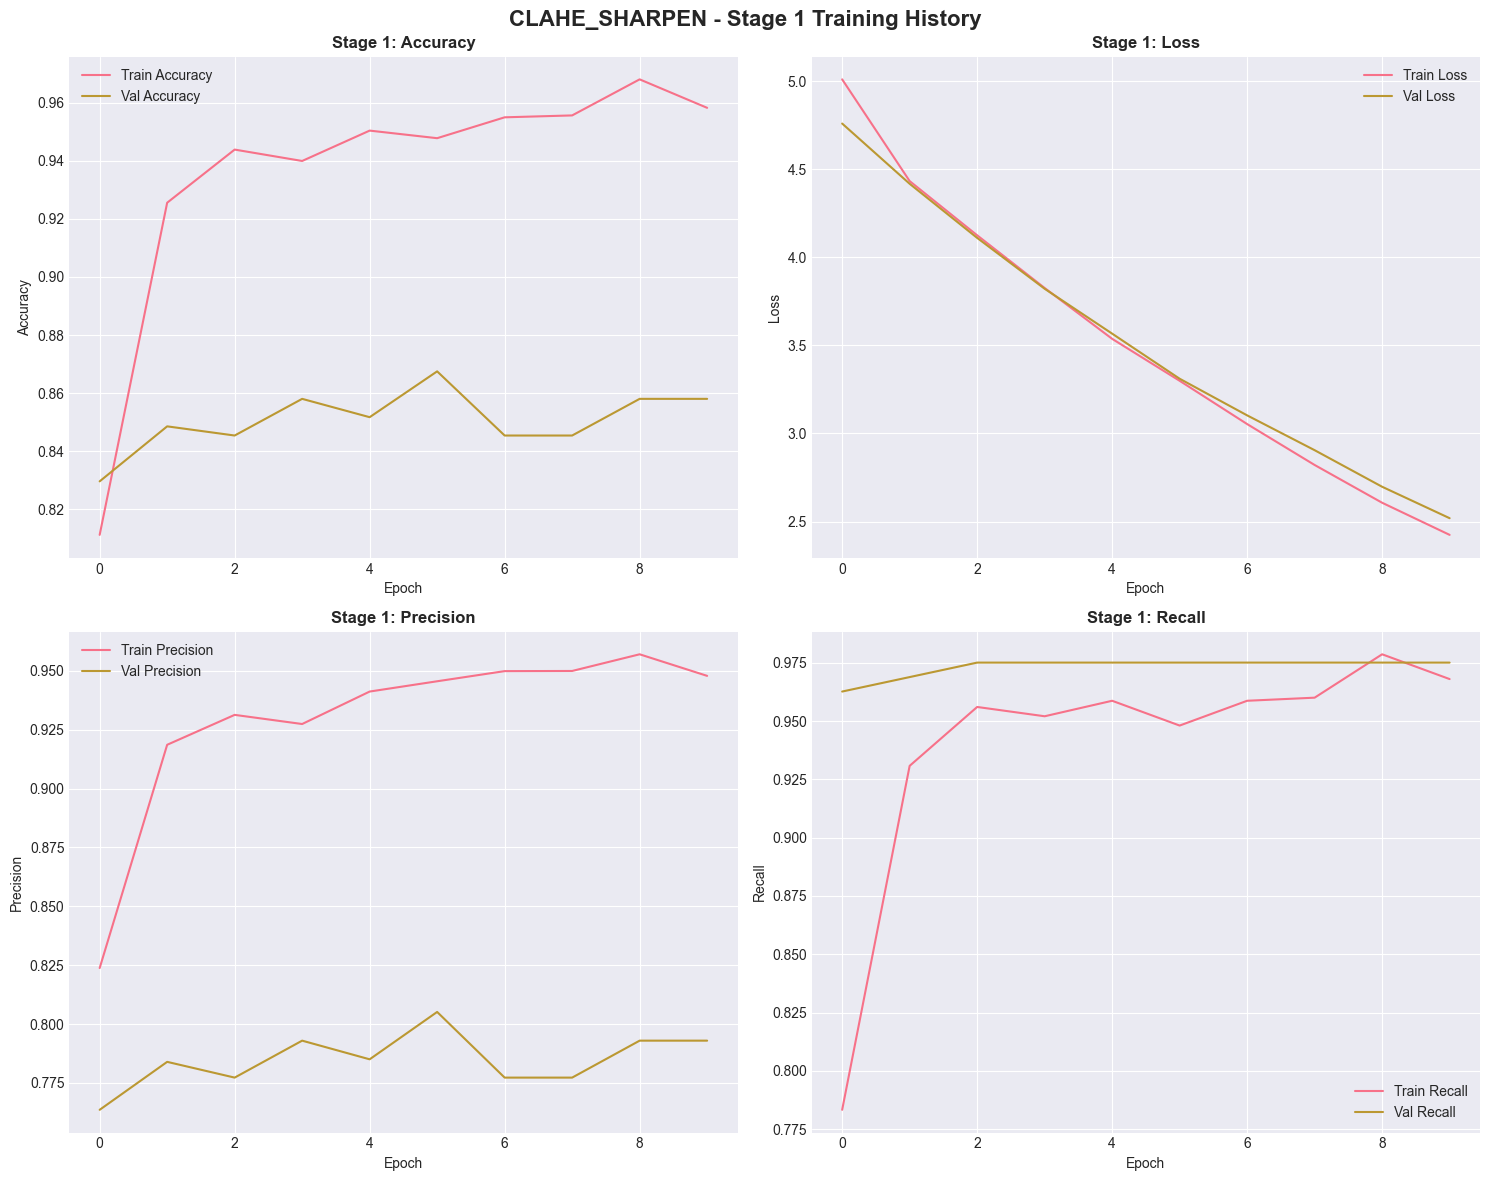


Stage 1 Final Metrics
Train Accuracy: 0.9582
Val Accuracy: 0.8580
Train Loss: 2.4242
Val Loss: 2.5188

Stage 1 complete - Ready for Stage 2 (Fine-tuning)
Next: Run Cell 8 (Training Stage 2)


In [20]:
# Training Stage 1 - Train Custom Layers Only

print("="*70)
print("TRAINING STAGE 1: Custom Layers Only")
print("="*70)

# Setup callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(RESULTS_DIR, f'{EXPERIMENT_NAME}_stage1_best.h5'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Compile model for Stage 1
print("\n" + "="*70)
print("Compiling model for Stage 1...")
print("="*70)
print(f"Optimizer: Adam")
print(f"Learning Rate: {LEARNING_RATE_1}")
print(f"Loss: binary_crossentropy")
print(f"Metrics: accuracy, precision, recall, AUC")
print("="*70)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_1),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Training Stage 1
print("\n" + "="*70)
print("Starting Training Stage 1...")
print("="*70)
print(f"Epochs: {EPOCHS_STAGE1}")
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Base model: FROZEN")
print(f"Custom layers: TRAINABLE")
print("="*70)

start_time = time.time()

history_stage1 = model.fit(
    train_data,
    epochs=EPOCHS_STAGE1,
    validation_data=val_data,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

stage1_time = time.time() - start_time

print("\n" + "="*70)
print("Training Stage 1 Complete")
print("="*70)
print(f"Total training time: {stage1_time:.2f} seconds ({stage1_time/60:.2f} minutes)")
print(f"Time per epoch: {stage1_time/EPOCHS_STAGE1:.2f} seconds")
print("="*70)

# Plot Stage 1 training history
print("\n" + "="*70)
print("Plotting Stage 1 training history...")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
axes[0, 0].plot(history_stage1.history['accuracy'], label='Train Accuracy')
axes[0, 0].plot(history_stage1.history['val_accuracy'], label='Val Accuracy')
axes[0, 0].set_title('Stage 1: Accuracy', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Loss
axes[0, 1].plot(history_stage1.history['loss'], label='Train Loss')
axes[0, 1].plot(history_stage1.history['val_loss'], label='Val Loss')
axes[0, 1].set_title('Stage 1: Loss', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history_stage1.history['precision'], label='Train Precision')
axes[1, 0].plot(history_stage1.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Stage 1: Precision', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history_stage1.history['recall'], label='Train Recall')
axes[1, 1].plot(history_stage1.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Stage 1: Recall', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle(f'{EXPERIMENT_NAME} - Stage 1 Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'{EXPERIMENT_NAME}_stage1_history.png'), dpi=300, bbox_inches='tight')
plt.show()

# Stage 1 final metrics
print("\n" + "="*70)
print("Stage 1 Final Metrics")
print("="*70)

final_train_acc = history_stage1.history['accuracy'][-1]
final_val_acc = history_stage1.history['val_accuracy'][-1]
final_train_loss = history_stage1.history['loss'][-1]
final_val_loss = history_stage1.history['val_loss'][-1]

print(f"Train Accuracy: {final_train_acc:.4f}")
print(f"Val Accuracy: {final_val_acc:.4f}")
print(f"Train Loss: {final_train_loss:.4f}")
print(f"Val Loss: {final_val_loss:.4f}")
print("="*70)

print("\nStage 1 complete - Ready for Stage 2 (Fine-tuning)")
print("Next: Run Cell 8 (Training Stage 2)")
print("="*70)

EVALUATING MODEL ON TEST SET

Generating predictions...
Processing 9 batches...

Predictions complete!
Total test samples: 264

Inference Time Statistics
Average batch inference time: 782.67 ms
Average image inference time: 24.46 ms
Throughput: ~41 images/second

Test Set Metrics
Accuracy:  0.6705 (67.05%)
Precision: 0.6568 (65.68%)
Recall:    0.9627 (96.27%)
F1-Score:  0.7809 (78.09%)
AUC-ROC:   0.8619

Confusion Matrix

                Predicted Normal   Predicted Cataract
Actual Normal   22               81             
Actual Cataract 6                155            

True Positives:  155
True Negatives:  22
False Positives: 81
False Negatives: 6

Sensitivity (Recall): 0.9627
Specificity:          0.2136

Detailed Classification Report
              precision    recall  f1-score   support

    Cataract     0.7857    0.2136    0.3359       103
      Normal     0.6568    0.9627    0.7809       161

    accuracy                         0.6705       264
   macro avg     0.7212    0.588

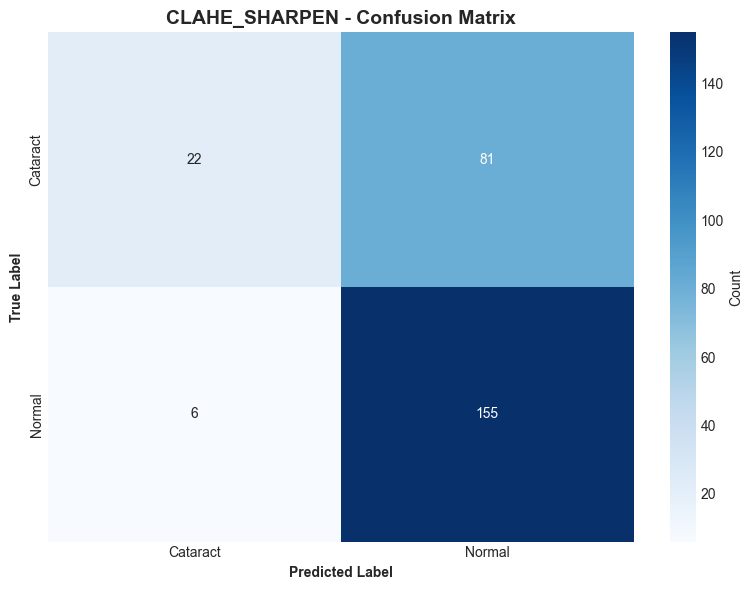


Plotting ROC curve...


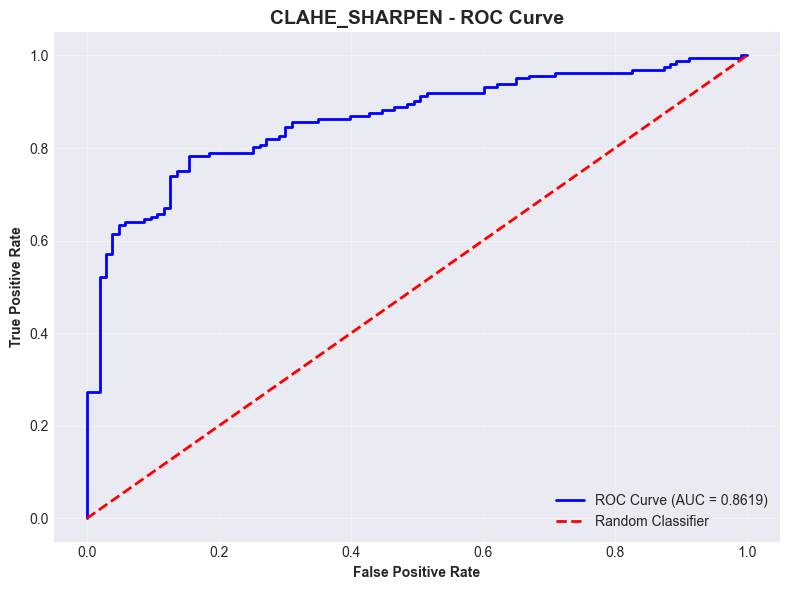


Complete Pipeline Performance
Preprocessing time: 1.75 ms
Inference time:     24.46 ms
Total time:         26.21 ms per image
Total throughput:   ~38 images/second

Combined Score (Mobile Deployment)
Accuracy Score:  0.6705 (weight: 60%)
Speed Score:     0.4758 (weight: 40%)
Combined Score:  0.5926

Results saved to: experiment_results\CLAHE_SHARPEN_results.csv

EVALUATION COMPLETE

Next: Run Cell 10 (Save Model)


In [21]:
# Evaluate Model on Test Set

print("="*70)
print("EVALUATING MODEL ON TEST SET")
print("="*70)

# Reset test data generator
test_data.reset()

# Predictions
print("\n" + "="*70)
print("Generating predictions...")
print("="*70)

# Measure inference time
inference_times = []
all_predictions = []
all_labels = []

print(f"Processing {len(test_data)} batches...")

for i in range(len(test_data)):
    batch_x, batch_y = test_data[i]
    
    # Measure inference time per batch
    start_time = time.time()
    batch_predictions = model.predict(batch_x, verbose=0)
    end_time = time.time()
    
    batch_time = (end_time - start_time) * 1000  # Convert to ms
    inference_times.append(batch_time)
    
    all_predictions.extend(batch_predictions)
    all_labels.extend(batch_y)

# Convert to numpy arrays
y_true = np.array(all_labels)
y_pred_prob = np.array(all_predictions)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate inference time statistics
avg_batch_inference_time = np.mean(inference_times)
avg_image_inference_time = avg_batch_inference_time / BATCH_SIZE

print(f"\nPredictions complete!")
print(f"Total test samples: {len(y_true)}")

# Inference time statistics
print("\n" + "="*70)
print("Inference Time Statistics")
print("="*70)
print(f"Average batch inference time: {avg_batch_inference_time:.2f} ms")
print(f"Average image inference time: {avg_image_inference_time:.2f} ms")
print(f"Throughput: ~{1000/avg_image_inference_time:.0f} images/second")
print("="*70)

# Calculate metrics
print("\n" + "="*70)
print("Test Set Metrics")
print("="*70)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"AUC-ROC:   {auc_score:.4f}")
print("="*70)

# Confusion Matrix
print("\n" + "="*70)
print("Confusion Matrix")
print("="*70)

cm = confusion_matrix(y_true, y_pred)
print(f"\n{' ':<15} Predicted Normal   Predicted Cataract")
print(f"Actual Normal   {cm[0,0]:<15}  {cm[0,1]:<15}")
print(f"Actual Cataract {cm[1,0]:<15}  {cm[1,1]:<15}")

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Positives:  {tp}")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Calculate additional metrics
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")
print("="*70)

# Classification Report
print("\n" + "="*70)
print("Detailed Classification Report")
print("="*70)

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Plot Confusion Matrix
print("\n" + "="*70)
print("Plotting confusion matrix...")
print("="*70)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax)

ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_title(f'{EXPERIMENT_NAME} - Confusion Matrix', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'{EXPERIMENT_NAME}_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot ROC Curve
print("\n" + "="*70)
print("Plotting ROC curve...")
print("="*70)

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title(f'{EXPERIMENT_NAME} - ROC Curve', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'{EXPERIMENT_NAME}_roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

# Calculate total time (preprocessing + inference)
total_time_per_image = experiment_info['avg_preprocessing_time_ms'] + avg_image_inference_time

print("\n" + "="*70)
print("Complete Pipeline Performance")
print("="*70)
print(f"Preprocessing time: {experiment_info['avg_preprocessing_time_ms']:.2f} ms")
print(f"Inference time:     {avg_image_inference_time:.2f} ms")
print(f"Total time:         {total_time_per_image:.2f} ms per image")
print(f"Total throughput:   ~{1000/total_time_per_image:.0f} images/second")
print("="*70)

# Calculate combined score (60% accuracy + 40% speed)
# Normalize speed score (lower time = higher score)
speed_score = 1 - (total_time_per_image / 50)  # Assume max 50ms is baseline
speed_score = max(0, min(1, speed_score))  # Clip to [0, 1]

combined_score = (accuracy * 0.6) + (speed_score * 0.4)

print("\n" + "="*70)
print("Combined Score (Mobile Deployment)")
print("="*70)
print(f"Accuracy Score:  {accuracy:.4f} (weight: 60%)")
print(f"Speed Score:     {speed_score:.4f} (weight: 40%)")
print(f"Combined Score:  {combined_score:.4f}")
print("="*70)

# Save results
results = {
    'experiment_name': EXPERIMENT_NAME,
    'preprocessing': PREPROCESSING_METHOD,
    'preprocessing_time_ms': experiment_info['avg_preprocessing_time_ms'],
    'inference_time_ms': round(avg_image_inference_time, 2),
    'total_time_ms': round(total_time_per_image, 2),
    'throughput_img_per_sec': round(1000/total_time_per_image, 0),
    'test_accuracy': round(accuracy, 4),
    'test_precision': round(precision, 4),
    'test_recall': round(recall, 4),
    'test_f1': round(f1, 4),
    'test_auc': round(auc_score, 4),
    'sensitivity': round(sensitivity, 4),
    'specificity': round(specificity, 4),
    'true_positives': int(tp),
    'true_negatives': int(tn),
    'false_positives': int(fp),
    'false_negatives': int(fn),
    'speed_score': round(speed_score, 4),
    'combined_score': round(combined_score, 4),
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save to CSV
results_df = pd.DataFrame([results])
csv_path = os.path.join(RESULTS_DIR, f'{EXPERIMENT_NAME}_results.csv')
results_df.to_csv(csv_path, index=False)

print(f"\nResults saved to: {csv_path}")

print("\n" + "="*70)
print("EVALUATION COMPLETE")
print("="*70)
print("\nNext: Run Cell 10 (Save Model)")
print("="*70)